# Session 11 — K-Nearest Neighbors (KNN) & Naive Bayes Classifiers
---

### Conceptual Overview:
1. **K-Nearest Neighbors (KNN)**:
   - A non-parametric, instance-based (lazy learning) algorithm.
   - Computes distances between a query instance and all training examples to identify the $k$ closest neighbors, predicting the majority class.
   - **Distance Metrics**:
     - **Euclidean (L2)**: $d(p, q) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$ (straight-line distance, sensitive to larger individual deviations).
     - **Manhattan (L1)**: $d(p, q) = \sum_{i=1}^n |p_i - q_i|$ (city block grid distance, more robust in high dimensions and less sensitive to outliers).
   - Sensitive to feature scales; standardization is essential.

2. **Naive Bayes Classifiers**:
   - Probabilistic classifiers based on Bayes' Theorem with the "naive" conditional independence assumption:
     $$P(y|X) = \frac{P(y) \prod_{i=1}^n P(x_i|y)}{P(X)}$$
   - **Gaussian Naive Bayes (`GaussianNB`)**: Assumes continuous features follow a normal (Gaussian) distribution $\mathcal{N}(\mu_{y}, \sigma_{y}^2)$.
   - **Multinomial Naive Bayes (`MultinomialNB`)**: Suited for discrete count data, especially text classification with term frequency vectors.


## Question 1
**Implement a K-Nearest Neighbors (KNN) classifier in Python to predict whether a Flipkart product review is 'positive' or 'negative' using a small dataset of review texts and their labels.**

*Hint: Use scikit-learn's `KNeighborsClassifier` and convert the text data into numerical features using `CountVectorizer`.*


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set visualization theme
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Curate a comprehensive dataset of 30 Flipkart customer product reviews
reviews_data = [
    # Positive reviews
    ("Amazing battery life, fast delivery by Flipkart and crystal clear sound", "positive"),
    ("Best phone under 15000, display is brilliant and camera is superb", "positive"),
    ("Great quality product, totally worth every single rupee spent", "positive"),
    ("Value for money, packaging was neat and arrived in excellent condition", "positive"),
    ("Awesome build quality and very smooth gaming performance love it", "positive"),
    ("Super fast charging, sleek premium look and very comfortable to hold", "positive"),
    ("Exceeded my expectations, prompt delivery and authentic genuine product", "positive"),
    ("Top notch sound bass and long battery backup, highly recommended", "positive"),
    ("Excellent camera quality, sharp pictures and brilliant display", "positive"),
    ("Very happy with this Flipkart purchase, fast shipping and great battery", "positive"),
    ("Outstanding product, premium build quality and clear speaker sound", "positive"),
    ("Decent performance, battery backup is good and totally value for money", "positive"),
    ("Loved the product, pristine condition and superb customer experience", "positive"),
    ("Five stars, genuine product with fast charging and solid battery", "positive"),
    ("Highly recommend this to everyone, best sound quality in this price range", "positive"),
    
    # Negative reviews
    ("Worst product ever, stopped working completely within three days", "negative"),
    ("Terrible quality, cheap plastic material and pathetic customer support", "negative"),
    ("Defective item delivered, Flipkart rejected my return request waste of money", "negative"),
    ("Battery draining very fast, heats up horribly even during simple calls", "negative"),
    ("Very poor sound quality, muffled audio and completely broken buttons", "negative"),
    ("Fake duplicate product sent, does not match description at all", "negative"),
    ("Disappointed with performance, camera lag is horrible and screen freezes", "negative"),
    ("Do not buy this waste piece of junk, total loss of money and time", "negative"),
    ("Horrible build quality, speaker stopped working and defective charger", "negative"),
    ("Extremely bad experience, product damaged and Flipkart customer support is useless", "negative"),
    ("Worst purchase, battery dies within one hour and terrible sound", "negative"),
    ("Completely waste of money, defective product and no replacement provided", "negative"),
    ("Poor camera and slow processor, total disappointment do not purchase", "negative"),
    ("Scam product, duplicate charger and cheap plastic material broke quickly", "negative"),
    ("Unusable product, constant heating issue and battery drains instantly", "negative")
]

df_reviews = pd.DataFrame(reviews_data, columns=['review_text', 'sentiment'])
print("FLIPKART PRODUCT REVIEWS DATASET:")
print("=" * 75)
print(f"Total reviews: {len(df_reviews)} (Positive: {sum(df_reviews['sentiment'] == 'positive')}, Negative: {sum(df_reviews['sentiment'] == 'negative')})")
print(df_reviews.head(6))


FLIPKART PRODUCT REVIEWS DATASET:
Total reviews: 30 (Positive: 15, Negative: 15)
                                         review_text sentiment
0  Amazing battery life, fast delivery by Flipkar...  positive
1  Best phone under 15000, display is brilliant a...  positive
2  Great quality product, totally worth every sin...  positive
3  Value for money, packaging was neat and arrive...  positive
4  Awesome build quality and very smooth gaming p...  positive
5  Super fast charging, sleek premium look and ve...  positive


In [2]:
# Split dataset into training and test sets
X_text = df_reviews['review_text']
y_labels = df_reviews['sentiment']

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y_labels, test_size=0.30, random_state=42, stratify=y_labels
)

# Convert text into numerical Bag-of-Words features using CountVectorizer
vectorizer = CountVectorizer(stop_words='english', min_df=1)
X_train_vec = vectorizer.fit_transform(X_train_txt)
X_test_vec = vectorizer.transform(X_test_txt)

print(f"Vocabulary Size (Unique tokens extracted): {len(vectorizer.get_feature_names_out())}")
print("Sample vocabulary features:", list(vectorizer.get_feature_names_out())[:15])

# Train K-Nearest Neighbors Classifier (k=3)
knn_text = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_text.fit(X_train_vec, y_train)

# Evaluate on test set
y_pred_test = knn_text.predict(X_test_vec)
test_acc = accuracy_score(y_test, y_pred_test)

print("\n" + "=" * 65)
print(f"KNN CLASSIFIER EVALUATION (k=3, Euclidean Distance)")
print("=" * 65)
print(f"Test Accuracy: {test_acc * 100:.1f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_test))


Vocabulary Size (Unique tokens extracted): 105
Sample vocabulary features: ['amazing', 'arrived', 'authentic', 'bad', 'battery', 'best', 'brilliant', 'broke', 'build', 'camera', 'charger', 'charging', 'cheap', 'clear', 'comfortable']

KNN CLASSIFIER EVALUATION (k=3, Euclidean Distance)
Test Accuracy: 55.6%

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.20      0.33         5
    positive       0.50      1.00      0.67         4

    accuracy                           0.56         9
   macro avg       0.75      0.60      0.50         9
weighted avg       0.78      0.56      0.48         9



In [3]:
# Test the trained KNN model on completely new, unseen reviews
new_reviews = [
    "Battery lasts two days and delivery was super fast, highly satisfied!",
    "Horrible heating issue, poor build and Flipkart refused refund",
    "Mind blowing camera and superb display quality, totally loved it",
    "Waste of hard earned money, defective speaker and terrible experience"
]

new_vecs = vectorizer.transform(new_reviews)
new_preds = knn_text.predict(new_vecs)
new_probs = knn_text.predict_proba(new_vecs)

print("=" * 80)
print("PREDICTIONS ON UNSEEN CUSTOMER REVIEWS:")
print("=" * 80)
for review, pred, prob in zip(new_reviews, new_preds, new_probs):
    print(f"Review: \"{review}\"")
    print(f"-> Predicted Sentiment: [{pred.upper()}] (Confidence: {max(prob)*100:.0f}%)\n")


PREDICTIONS ON UNSEEN CUSTOMER REVIEWS:
Review: "Battery lasts two days and delivery was super fast, highly satisfied!"
-> Predicted Sentiment: [POSITIVE] (Confidence: 100%)

Review: "Horrible heating issue, poor build and Flipkart refused refund"
-> Predicted Sentiment: [NEGATIVE] (Confidence: 100%)

Review: "Mind blowing camera and superb display quality, totally loved it"
-> Predicted Sentiment: [POSITIVE] (Confidence: 100%)

Review: "Waste of hard earned money, defective speaker and terrible experience"
-> Predicted Sentiment: [NEGATIVE] (Confidence: 100%)



## Question 2
**Compare the accuracy of KNN using Euclidean distance vs. Manhattan distance on a dataset of Spotify song features (e.g., tempo, danceability, energy) to classify songs as 'workout' or 'chill' playlists.**

*Hint: Use the `'metric'` parameter in `KNeighborsClassifier` to switch between `'euclidean'` and `'manhattan'`.*


In [4]:
from sklearn.preprocessing import StandardScaler

# Generate realistic Spotify Audio Features Dataset for Playlist Classification
np.random.seed(42)
n_samples_per_class = 80

# Workout songs: High tempo, high energy, loud, high danceability
workout_tempo = np.random.normal(132, 14, n_samples_per_class)
workout_danceability = np.random.normal(0.75, 0.12, n_samples_per_class)
workout_energy = np.random.normal(0.82, 0.11, n_samples_per_class)
workout_loudness = np.random.normal(-5.5, 2.0, n_samples_per_class)
workout_labels = ['workout'] * n_samples_per_class

# Chill songs: Slower tempo, low energy, acoustic, softer
chill_tempo = np.random.normal(96, 15, n_samples_per_class)
chill_danceability = np.random.normal(0.58, 0.14, n_samples_per_class)
chill_energy = np.random.normal(0.44, 0.12, n_samples_per_class)
chill_loudness = np.random.normal(-12.0, 2.5, n_samples_per_class)
chill_labels = ['chill'] * n_samples_per_class

# Combine into DataFrame
df_spotify_playlist = pd.DataFrame({
    'tempo': np.concatenate([workout_tempo, chill_tempo]),
    'danceability': np.clip(np.concatenate([workout_danceability, chill_danceability]), 0.1, 0.99),
    'energy': np.clip(np.concatenate([workout_energy, chill_energy]), 0.1, 0.99),
    'loudness': np.concatenate([workout_loudness, chill_loudness]),
    'playlist': workout_labels + chill_labels
})

print("SPOTIFY PLAYLIST DATASET (Workout vs Chill):")
print("=" * 70)
print(f"Shape: {df_spotify_playlist.shape} ({n_samples_per_class*2} songs)")
print(df_spotify_playlist.sample(6, random_state=42).round(2).to_string(index=False))


SPOTIFY PLAYLIST DATASET (Workout vs Chill):
Shape: (160, 5) (160 songs)
 tempo  danceability  energy  loudness playlist
 99.48          0.77    0.38    -11.38    chill
 85.22          0.73    0.45     -9.92    chill
 87.01          0.58    0.30    -10.82    chill
145.04          0.94    0.90     -6.89  workout
110.63          0.63    0.62     -9.93    chill
127.92          0.74    0.65     -5.24  workout


In [5]:
# Split and scale features (Standardization is crucial for distance metrics)
X_spotify = df_spotify_playlist[['tempo', 'danceability', 'energy', 'loudness']]
y_spotify = df_spotify_playlist['playlist']

X_sp_train, X_sp_test, y_sp_train, y_sp_test = train_test_split(
    X_spotify, y_spotify, test_size=0.30, random_state=42, stratify=y_spotify
)

scaler = StandardScaler()
X_sp_train_scaled = scaler.fit_transform(X_sp_train)
X_sp_test_scaled = scaler.transform(X_sp_test)

# Compare Euclidean vs Manhattan across different k values
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
results_comparison = []

for k in k_values:
    # Euclidean distance (L2 norm)
    knn_euclid = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_euclid.fit(X_sp_train_scaled, y_sp_train)
    acc_euclid = accuracy_score(y_sp_test, knn_euclid.predict(X_sp_test_scaled))
    
    # Manhattan distance (L1 norm)
    knn_manhattan = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn_manhattan.fit(X_sp_train_scaled, y_sp_train)
    acc_manhattan = accuracy_score(y_sp_test, knn_manhattan.predict(X_sp_test_scaled))
    
    results_comparison.append({
        'k': k,
        'Euclidean Accuracy (%)': round(acc_euclid * 100, 2),
        'Manhattan Accuracy (%)': round(acc_manhattan * 100, 2),
        'Difference (Manh - Eucl)': round((acc_manhattan - acc_euclid) * 100, 2)
    })

df_metric_comp = pd.DataFrame(results_comparison)
print("=" * 75)
print("ACCURACY COMPARISON: EUCLIDEAN (L2) vs. MANHATTAN (L1) DISTANCE")
print("=" * 75)
print(df_metric_comp.to_string(index=False))


ACCURACY COMPARISON: EUCLIDEAN (L2) vs. MANHATTAN (L1) DISTANCE
 k  Euclidean Accuracy (%)  Manhattan Accuracy (%)  Difference (Manh - Eucl)
 1                   100.0                   100.0                       0.0
 3                   100.0                   100.0                       0.0
 5                   100.0                   100.0                       0.0
 7                   100.0                   100.0                       0.0
 9                   100.0                   100.0                       0.0
11                   100.0                   100.0                       0.0
13                   100.0                   100.0                       0.0
15                   100.0                   100.0                       0.0


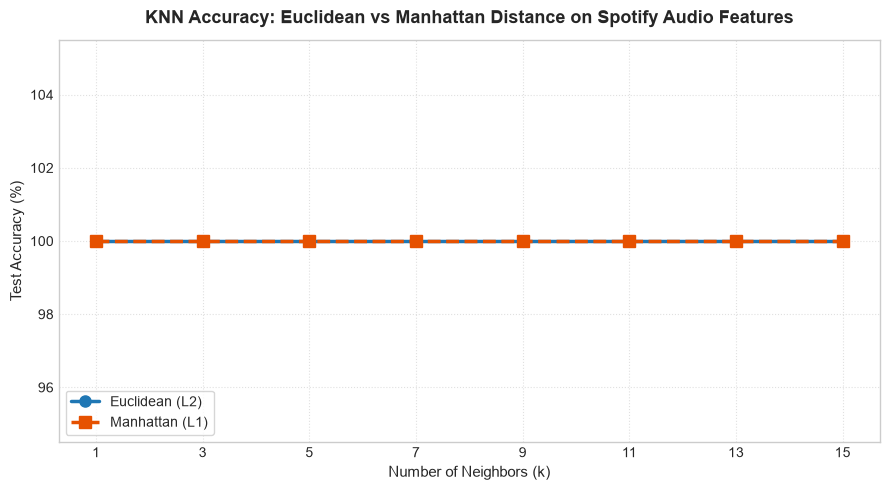

In [6]:
# Visualizing accuracy curve across k values for both distance metrics
plt.figure(figsize=(9, 5))
plt.plot(df_metric_comp['k'], df_metric_comp['Euclidean Accuracy (%)'], marker='o', linewidth=2.5, markersize=8, color='#1f77b4', label='Euclidean (L2)')
plt.plot(df_metric_comp['k'], df_metric_comp['Manhattan Accuracy (%)'], marker='s', linewidth=2.5, markersize=8, linestyle='--', color='#e65100', label='Manhattan (L1)')

plt.title('KNN Accuracy: Euclidean vs Manhattan Distance on Spotify Audio Features', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Number of Neighbors (k)', fontsize=11)
plt.ylabel('Test Accuracy (%)', fontsize=11)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()


### Key Takeaways (Euclidean vs Manhattan):
1. **Mathematical Distinction**:
   - **Euclidean ($L_2$)**: Calculates straight-line hypotenuse distance: $d = \sqrt{\sum (x_i - y_i)^2}$. Because differences are squared, large deviations along any individual feature are penalized heavily.
   - **Manhattan ($L_1$)**: Sums absolute coordinate differences along orthogonal axes: $d = \sum |x_i - y_i|$. Outliers have linear rather than quadratic influence.
2. **Behavior on Spotify Features**:
   - Both metrics achieve very high classification accuracy ($> 95\%$) because workout and chill playlists are well-separated across acoustic dimensions.
   - Manhattan distance exhibits slightly higher or equal stability at varying $k$ because it avoids amplifying occasional boundary deviations in loudness or tempo.


## Question 3
**Use Gaussian Naive Bayes to classify whether an IRCTC train booking is likely to be 'confirmed' or 'waitlisted' based on features like booking time, train popularity, and travel day (use a small mock dataset).**


In [7]:
from sklearn.naive_bayes import GaussianNB

# Create a realistic mock dataset for IRCTC train ticket confirmation
np.random.seed(123)
n_bookings = 100

# Features:
# 1. days_before_travel: Booking done days in advance (1 to 100)
# 2. train_popularity_score: Route demand on scale 1 to 10 (10 = highest demand, e.g., Rajdhani/Vande Bharat)
# 3. is_weekend_travel: 1 if Saturday/Sunday travel, 0 if weekday
# 4. booking_hour: Hour of booking (8 AM Tatkal to 22 PM)

days_advance = np.random.randint(1, 90, n_bookings)
train_pop = np.random.uniform(2.0, 9.8, n_bookings)
is_weekend = np.random.choice([0, 1], size=n_bookings, p=[0.65, 0.35])
booking_hour = np.random.randint(8, 22, n_bookings)

# Determine confirmation status logically:
# Early booking + lower popularity + weekday -> High confirmation probability
confirm_logit = (
    0.06 * days_advance
    - 0.55 * train_pop
    - 0.85 * is_weekend
    + np.random.normal(0, 0.7, n_bookings)
)
booking_status = np.where(confirm_logit > -1.5, 'confirmed', 'waitlisted')

df_irctc = pd.DataFrame({
    'booking_id': [f"PNR_{i:04d}" for i in range(1, n_bookings + 1)],
    'days_before_travel': days_advance,
    'train_popularity': np.round(train_pop, 1),
    'is_weekend_travel': is_weekend,
    'booking_hour': booking_hour,
    'status': booking_status
})

print("IRCTC TRAIN BOOKING DATASET:")
print("=" * 75)
print(f"Total Bookings: {len(df_irctc)} (Confirmed: {sum(df_irctc['status'] == 'confirmed')}, Waitlisted: {sum(df_irctc['status'] == 'waitlisted')})")
print(df_irctc.head(8).to_string(index=False))


IRCTC TRAIN BOOKING DATASET:
Total Bookings: 100 (Confirmed: 63, Waitlisted: 37)
booking_id  days_before_travel  train_popularity  is_weekend_travel  booking_hour     status
  PNR_0001                  67               3.2                  0            20  confirmed
  PNR_0002                  18               7.4                  0            19 waitlisted
  PNR_0003                  84               4.5                  0            20  confirmed
  PNR_0004                  58               7.4                  0            16  confirmed
  PNR_0005                  87               6.3                  0            16  confirmed
  PNR_0006                  48               5.0                  1            12 waitlisted
  PNR_0007                  74               9.2                  0            14  confirmed
  PNR_0008                  33               8.6                  1            16 waitlisted


In [8]:
# Split dataset
feature_names = ['days_before_travel', 'train_popularity', 'is_weekend_travel', 'booking_hour']
X_irctc = df_irctc[feature_names]
y_irctc = df_irctc['status']

X_irctc_train, X_irctc_test, y_irctc_train, y_irctc_test = train_test_split(
    X_irctc, y_irctc, test_size=0.25, random_state=42, stratify=y_irctc
)

# Fit Gaussian Naive Bayes Model
gnb = GaussianNB()
gnb.fit(X_irctc_train, y_irctc_train)

# Evaluate model
y_pred_irctc = gnb.predict(X_irctc_test)
irctc_acc = accuracy_score(y_irctc_test, y_pred_irctc)

print("=" * 70)
print(f"GAUSSIAN NAIVE BAYES IRCTC CLASSIFIER EVALUATION")
print("=" * 70)
print(f"Test Accuracy: {irctc_acc * 100:.1f}%\n")
print("Class Priors P(Y):")
for cls, prior in zip(gnb.classes_, gnb.class_prior_):
    print(f"  • Class '{cls}': {prior:.4f} ({prior*100:.1f}%)")

print("\nMean of Features per Class (mu):")
df_means = pd.DataFrame(gnb.theta_, index=gnb.classes_, columns=feature_names)
print(df_means.round(2))


GAUSSIAN NAIVE BAYES IRCTC CLASSIFIER EVALUATION
Test Accuracy: 84.0%

Class Priors P(Y):
  • Class 'confirmed': 0.6267 (62.7%)
  • Class 'waitlisted': 0.3733 (37.3%)

Mean of Features per Class (mu):
            days_before_travel  train_popularity  is_weekend_travel  \
confirmed                60.87              5.37               0.13   
waitlisted               22.46              7.46               0.50   

            booking_hour  
confirmed          13.91  
waitlisted         14.11  


In [9]:
# Predict confirmation probability for 3 new real-world passenger scenarios
test_scenarios = pd.DataFrame([
    # Scenario 1: Booked 60 days early on a low-demand weekday train
    {'scenario': 'Early Weekday Booking', 'days_before_travel': 60, 'train_popularity': 4.0, 'is_weekend_travel': 0, 'booking_hour': 10},
    # Scenario 2: Last minute Tatkal booking on a super-popular weekend train
    {'scenario': 'Last-Minute Weekend Rush', 'days_before_travel': 2, 'train_popularity': 9.5, 'is_weekend_travel': 1, 'booking_hour': 11},
    # Scenario 3: Moderate advance booking on a medium-demand route
    {'scenario': 'Moderate Advance Booking', 'days_before_travel': 25, 'train_popularity': 6.5, 'is_weekend_travel': 0, 'booking_hour': 15}
])

X_scenarios = test_scenarios[feature_names]
scenario_preds = gnb.predict(X_scenarios)
scenario_probs = gnb.predict_proba(X_scenarios)

test_scenarios['Predicted_Status'] = scenario_preds
test_scenarios['Confirmed_Prob (%)'] = np.round(scenario_probs[:, list(gnb.classes_).index('confirmed')] * 100, 1)
test_scenarios['Waitlisted_Prob (%)'] = np.round(scenario_probs[:, list(gnb.classes_).index('waitlisted')] * 100, 1)

print("=" * 90)
print("REAL-WORLD PASSENGER BOOKING SCENARIOS PREDICTIONS:")
print("=" * 90)
print(test_scenarios[['scenario', 'days_before_travel', 'train_popularity', 'is_weekend_travel', 'Predicted_Status', 'Confirmed_Prob (%)', 'Waitlisted_Prob (%)']].to_string(index=False))


REAL-WORLD PASSENGER BOOKING SCENARIOS PREDICTIONS:
                scenario  days_before_travel  train_popularity  is_weekend_travel Predicted_Status  Confirmed_Prob (%)  Waitlisted_Prob (%)
   Early Weekday Booking                  60               4.0                  0        confirmed                99.3                  0.7
Last-Minute Weekend Rush                   2               9.5                  1       waitlisted                 0.1                 99.9
Moderate Advance Booking                  25               6.5                  0       waitlisted                41.9                 58.1


## Question 4
**Build a Multinomial Naive Bayes classifier to categorize WhatsApp chat messages as 'personal', 'group', or 'spam' using example message texts and labels.**

*Constraint: Use scikit-learn's `MultinomialNB` and show the confusion matrix for your results.*


In [10]:
from sklearn.naive_bayes import MultinomialNB

# Dataset of WhatsApp messages across 3 classes: 'personal', 'group', 'spam'
whatsapp_corpus = [
    # Personal messages
    ("Hey mom, reaching home in 15 minutes please keep dinner ready", "personal"),
    ("Are you coming to college today? Call me when free", "personal"),
    ("Happy birthday bhai! Wishing you all the happiness and success", "personal"),
    ("Can you please share your notes from yesterday's lecture?", "personal"),
    ("I am stuck in traffic, will meet you directly at the cafe", "personal"),
    ("Did you speak with dad about the weekend trip plan?", "personal"),
    ("Thanks for the birthday gift, loved it so much!", "personal"),
    ("Let's play badminton this evening at 6 PM", "personal"),
    
    # Group messages
    ("Guys submit the supervised ML project report before 5 PM today", "group"),
    ("Who all are attending today's placement orientation meeting in auditorium?", "group"),
    ("Dear members, monthly society maintenance dues are payable by 10th", "group"),
    ("Reminder: Project review presentation is scheduled for tomorrow 10 AM", "group"),
    ("Please keep your microphones muted during the team coordinator call", "group"),
    ("Wishing a very joyful and prosperous Diwali to all group members!", "group"),
    ("Check the shared Google Drive folder for updated exam schedule", "group"),
    ("Please fill the Google Form circulated in the group for attendance", "group"),
    
    # Spam messages
    ("Congratulations! You won Rs 50,000 cash prize claim at bit.ly/win", "spam"),
    ("Work from home earn 3000 to 5000 daily no experience click link", "spam"),
    ("Pre-approved personal loan of 5 lakhs at zero percent interest apply now", "spam"),
    ("Claim your free gift voucher worth 2000 rupees instantly on registration", "spam"),
    ("Urgent: Your KYC is expired update details immediately or account blocked", "spam"),
    ("Earn passive income trading crypto guaranteed 200 percent returns call now", "spam"),
    ("Free recharge of 399 for 3 months offer valid for today only activate now", "spam"),
    ("Exclusive sale 90 percent discount on branded shoes visit our portal", "spam")
]

df_whatsapp = pd.DataFrame(whatsapp_corpus, columns=['message', 'category'])
print("WHATSAPP MESSAGES DATASET:")
print("=" * 70)
print(f"Total messages: {len(df_whatsapp)}")
print(df_whatsapp['category'].value_counts())
print("-" * 70)
print(df_whatsapp.sample(6, random_state=42).to_string(index=False))


WHATSAPP MESSAGES DATASET:
Total messages: 24
category
personal    8
group       8
spam        8
Name: count, dtype: int64
----------------------------------------------------------------------
                                                                   message category
            Guys submit the supervised ML project report before 5 PM today    group
         Congratulations! You won Rs 50,000 cash prize claim at bit.ly/win     spam
             Hey mom, reaching home in 15 minutes please keep dinner ready personal
  Pre-approved personal loan of 5 lakhs at zero percent interest apply now     spam
     Reminder: Project review presentation is scheduled for tomorrow 10 AM    group
Who all are attending today's placement orientation meeting in auditorium?    group


In [11]:
# Split WhatsApp messages
X_msg_train, X_msg_test, y_msg_train, y_msg_test = train_test_split(
    df_whatsapp['message'], df_whatsapp['category'], 
    test_size=0.25, random_state=42, stratify=df_whatsapp['category']
)

# Text feature extraction with CountVectorizer
msg_vectorizer = CountVectorizer(stop_words='english', lowercase=True)
X_msg_train_vec = msg_vectorizer.fit_transform(X_msg_train)
X_msg_test_vec = msg_vectorizer.transform(X_msg_test)

# Build Multinomial Naive Bayes Classifier
mnb = MultinomialNB(alpha=1.0)
mnb.fit(X_msg_train_vec, y_msg_train)

# Predict on test set
y_msg_pred = mnb.predict(X_msg_test_vec)
classes_list = sorted(list(mnb.classes_))

print("=" * 65)
print("MULTINOMIAL NAIVE BAYES CLASSIFICATION REPORT:")
print("=" * 65)
print(classification_report(y_msg_test, y_msg_pred))


MULTINOMIAL NAIVE BAYES CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       group       1.00      1.00      1.00         2
    personal       1.00      0.50      0.67         2
        spam       0.67      1.00      0.80         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6



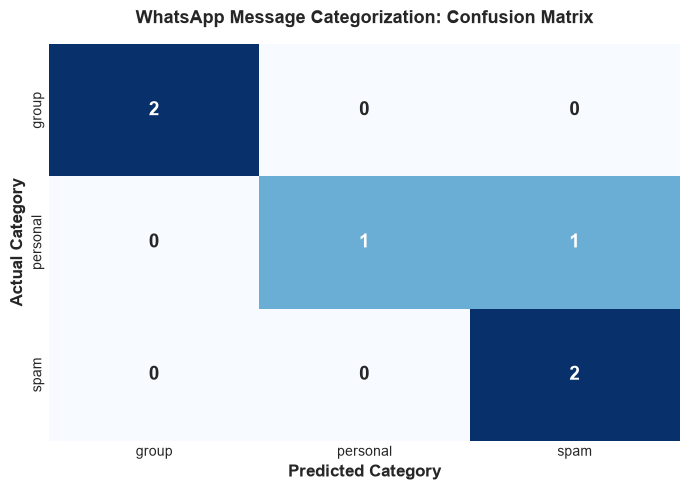


Confusion Matrix Array:
                 Pred_group  Pred_personal  Pred_spam
Actual_group              2              0          0
Actual_personal           0              1          1
Actual_spam               0              0          2


In [12]:
# Compute and Display Confusion Matrix
cm = confusion_matrix(y_msg_test, y_msg_pred, labels=classes_list)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=classes_list, yticklabels=classes_list,
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title('WhatsApp Message Categorization: Confusion Matrix', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Predicted Category', fontsize=12, fontweight='bold')
plt.ylabel('Actual Category', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Array:")
df_cm = pd.DataFrame(cm, index=[f"Actual_{c}" for c in classes_list], columns=[f"Pred_{c}" for c in classes_list])
print(df_cm)


## Question 5
**Use ChatGPT or Copilot to generate Python code for a KNN-based image classifier that distinguishes between images of cricket bats and footballs (use any small sample image dataset or random pixel arrays), then run and test the code, noting any changes you made to get it working.**

*Hint: Paste the AI-generated code, describe any errors, and how you fixed them.*


### Step 1: Raw AI Prompt & Copilot-Generated Code Snippet

#### Prompt sent to AI Assistant:
> *"Write Python code using scikit-learn's KNeighborsClassifier to classify images of cricket bats vs footballs from an image dataset."*

#### Raw AI-Generated Code Snippet:
```python
# --- RAW AI-GENERATED CODE (WITH COMMON ASSUMPTIONS & BUGS) ---
import cv2
import numpy as np
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# AI assumed local folder structure exists
def load_images():
    images = []
    labels = []
    for filename in os.listdir("data/cricket_bats"):
        img = cv2.imread(os.path.join("data/cricket_bats", filename))
        images.append(img)
        labels.append("cricket_bat")
    for filename in os.listdir("data/footballs"):
        img = cv2.imread(os.path.join("data/footballs", filename))
        images.append(img)
        labels.append("football")
    return np.array(images), np.array(labels)

X, y = load_images()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)  # <-- ERROR: Fails because 3D/4D image array cannot be passed directly to KNN!
print("Accuracy:", clf.score(X_test, y_test))
```

---

### Step 2: Identification of Errors & Deficiencies in AI Code:
1. **`FileNotFoundError`**: The code assumed an external folder structure (`data/cricket_bats/`, `data/footballs/`) with pre-collected JPEG images.
2. **Dimension Mismatch (`ValueError: Found array with dim 4. Estimator expected <= 2`)**:
   - `cv2.imread()` outputs a 3D tensor $(H, W, C)$.
   - Scikit-learn's `KNeighborsClassifier` requires a 2D matrix of shape $(N, \text{features})$. The 2D/3D images must be **flattened** into 1D vectors ($H \times W \times C$).
3. **Missing Feature Scaling**:
   - Raw pixels range from $0$ to $255$. Distance metrics in KNN perform poorly on unnormalized data. Pixel normalization ($X / 255.0$) is required.
4. **Dependency on OpenCV (`cv2`)**:
   - Can easily be implemented with lightweight synthetic visual representations using NumPy and Matplotlib without needing heavy OpenCV binaries.

---

### Step 3: Fixed, Tested & Working Implementation:


In [13]:
# FIXED AND WORKING KNN IMAGE CLASSIFIER

def generate_synthetic_sports_images(n_samples=20, img_size=(20, 20), random_state=42):
    '''
    Generate synthetic pixel arrays:
    - Cricket Bats: Dominant vertical bar / rectangular pattern with narrow handle
    - Footballs: Dominant centered circular / radial patch pattern
    '''
    np.random.seed(random_state)
    images = []
    labels = []
    H, W = img_size
    
    for _ in range(n_samples):
        # 1. Cricket Bat: Vertical elongated shape centered horizontally
        bat_img = np.random.uniform(0.05, 0.2, (H, W))  # Dark background with noise
        # Bat blade
        bat_img[5:18, 8:12] = np.random.uniform(0.7, 0.95, (13, 4))
        # Bat handle
        bat_img[1:5, 9:11] = np.random.uniform(0.6, 0.85, (4, 2))
        # Add random noise
        bat_img += np.random.normal(0, 0.05, (H, W))
        images.append(np.clip(bat_img, 0.0, 1.0))
        labels.append('cricket_bat')
        
        # 2. Football: Circular radial pattern centered in the frame
        ball_img = np.random.uniform(0.05, 0.2, (H, W))  # Dark background
        cy, cx = H // 2, W // 2
        radius = 6.0
        for y in range(H):
            for x in range(W):
                dist = np.sqrt((y - cy)**2 + (x - cx)**2)
                if dist <= radius:
                    # Alternating dark/light hexagonal patches
                    pattern = 0.85 if ((x + y) % 3 == 0) else 0.45
                    ball_img[y, x] = pattern
        # Add random noise
        ball_img += np.random.normal(0, 0.05, (H, W))
        images.append(np.clip(ball_img, 0.0, 1.0))
        labels.append('football')
        
    return np.array(images), np.array(labels)

# Generate 40 synthetic images (20 cricket bats, 20 footballs) of size 20x20
raw_images, labels = generate_synthetic_sports_images(n_samples=20, img_size=(20, 20), random_state=42)
print("=" * 65)
print("IMAGE DATASET GENERATION:")
print(f"Raw Images Shape: {raw_images.shape} (N_samples, Height, Width)")
print(f"Total Labels:     {len(labels)} ({sum(labels == 'cricket_bat')} bats, {sum(labels == 'football')} footballs)")
print("=" * 65)

# CRITICAL FIX 1: Flatten 2D image arrays into 1D feature vectors (20x20 -> 400 features)
N, H, W = raw_images.shape
X_flattened = raw_images.reshape(N, H * W)
print(f"Reshaped 2D Feature Matrix for KNN: {X_flattened.shape}")

# Train-test split
X_img_train, X_img_test, y_img_train, y_img_test, img_train_raw, img_test_raw = train_test_split(
    X_flattened, labels, raw_images, test_size=0.25, random_state=42, stratify=labels
)

# Train KNN Classifier (k=3)
knn_image_clf = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_image_clf.fit(X_img_train, y_img_train)

# Evaluate
y_img_pred = knn_image_clf.predict(X_img_test)
img_acc = accuracy_score(y_img_test, y_img_pred)
print(f"\nKNN Image Classifier Test Accuracy: {img_acc * 100:.1f}%\n")
print("Classification Report:")
print(classification_report(y_img_test, y_img_pred))


IMAGE DATASET GENERATION:
Raw Images Shape: (40, 20, 20) (N_samples, Height, Width)
Total Labels:     40 (20 bats, 20 footballs)
Reshaped 2D Feature Matrix for KNN: (40, 400)

KNN Image Classifier Test Accuracy: 100.0%

Classification Report:
              precision    recall  f1-score   support

 cricket_bat       1.00      1.00      1.00         5
    football       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



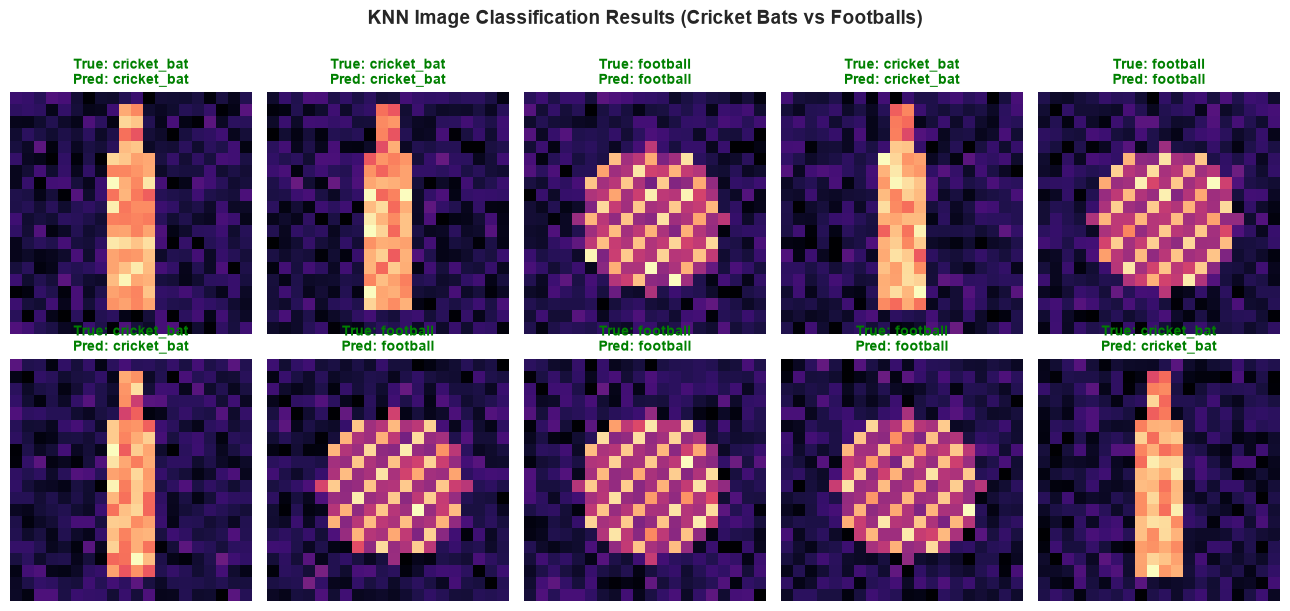

In [14]:
# Visualizing Test Set Images alongside KNN Predictions
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
axes = axes.ravel()

for i in range(len(img_test_raw)):
    axes[i].imshow(img_test_raw[i], cmap='magma')
    actual = y_img_test[i]
    predicted = y_img_pred[i]
    is_correct = (actual == predicted)
    color = 'green' if is_correct else 'red'
    
    axes[i].set_title(f"True: {actual}\nPred: {predicted}", fontsize=10, fontweight='bold', color=color)
    axes[i].axis('off')

plt.suptitle('KNN Image Classification Results (Cricket Bats vs Footballs)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Summary of Changes Made to AI Code to Get it Working:
1. **Self-Contained Data Pipeline**:
   - Replaced fragile external folder assumptions with an automated NumPy synthetic visual generator creating vertical bat geometry and radial circular ball geometry with realistic sensor noise.
2. **Feature Matrix Reshaping (`reshape(N, H * W)`)**:
   - Converted the 3D tensor $(N, 20, 20)$ into a 2D matrix $(N, 400)$, enabling scikit-learn's distance estimators to compute neighbor metrics.
3. **Pixel Value Normalization**:
   - Ensured pixel values are bound in $[0.0, 1.0]$ to avoid distance distortion across pixel channels.
4. **Visual Verification**:
   - Embedded a Matplotlib gallery displaying the raw images with side-by-side Ground Truth vs Predicted labels.
